# Shallow 1 Dimension Convolutional Network

- splitto train, val, test
- data augmentation sul train set originale con step e linear
- scaling fit su train e transform su validation/test
- creazione tabella lag features con sequenze su tutti i set
- reshape per CNN: da (samples, timesteps) a (samples, timesteps, 1) [1 perchè univariato]

Input Layer: (Batch, 60, 1)

Conv1D Layer:
Filters: 16 (cerca 16 pattern diversi).
Kernel Size: 3 (guarda 3 punti alla volta).
Activation: ReLU.

Pooling Layer:
Type: MaxPooling1D.
Pool Size: 2 (dimezza la dimensione temporale: da 60 a 30).

Flatten Layer:
Trasforma il tensore (Batch, 30, 16) in un vettore piatto di dimensione 480 (30 * 16).

Dense Layer (Head):
Un layer denso intermedio (es. 64 neuroni) + ReLU.

Output Layer:
1 neurone (per regressione o classificazione binaria).

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from src.config import COLORS
import src.pipeline as pipe
import src.models as mod
import src.models.nn as nn
import src.evaluation as eval
import src.visualization as visual
import src.reporting as rep
import pandas as pd

In [11]:
INDICATORS = ['Fertilizer consumption (% of fertilizer production)']

In [25]:
df = pipe.load_data()

Dataset caricato: 65 anni, 28 variabili.


============================== FERTILIZER CONSUMPTION (% OF FERTILIZER PRODUCTION) ==============================
Train: 1961-2003 (43 obs)
Val:   2004-2013 (10 obs)
Test:  2014-2022 (9 obs)
Cartella creata: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\augmentation
Grafico salvato in: C:\Users\oldan\Desktop\RuralDevelopment\progetto-tirocinio\results\plots\augmentation\augment_fertilizer_percent.png


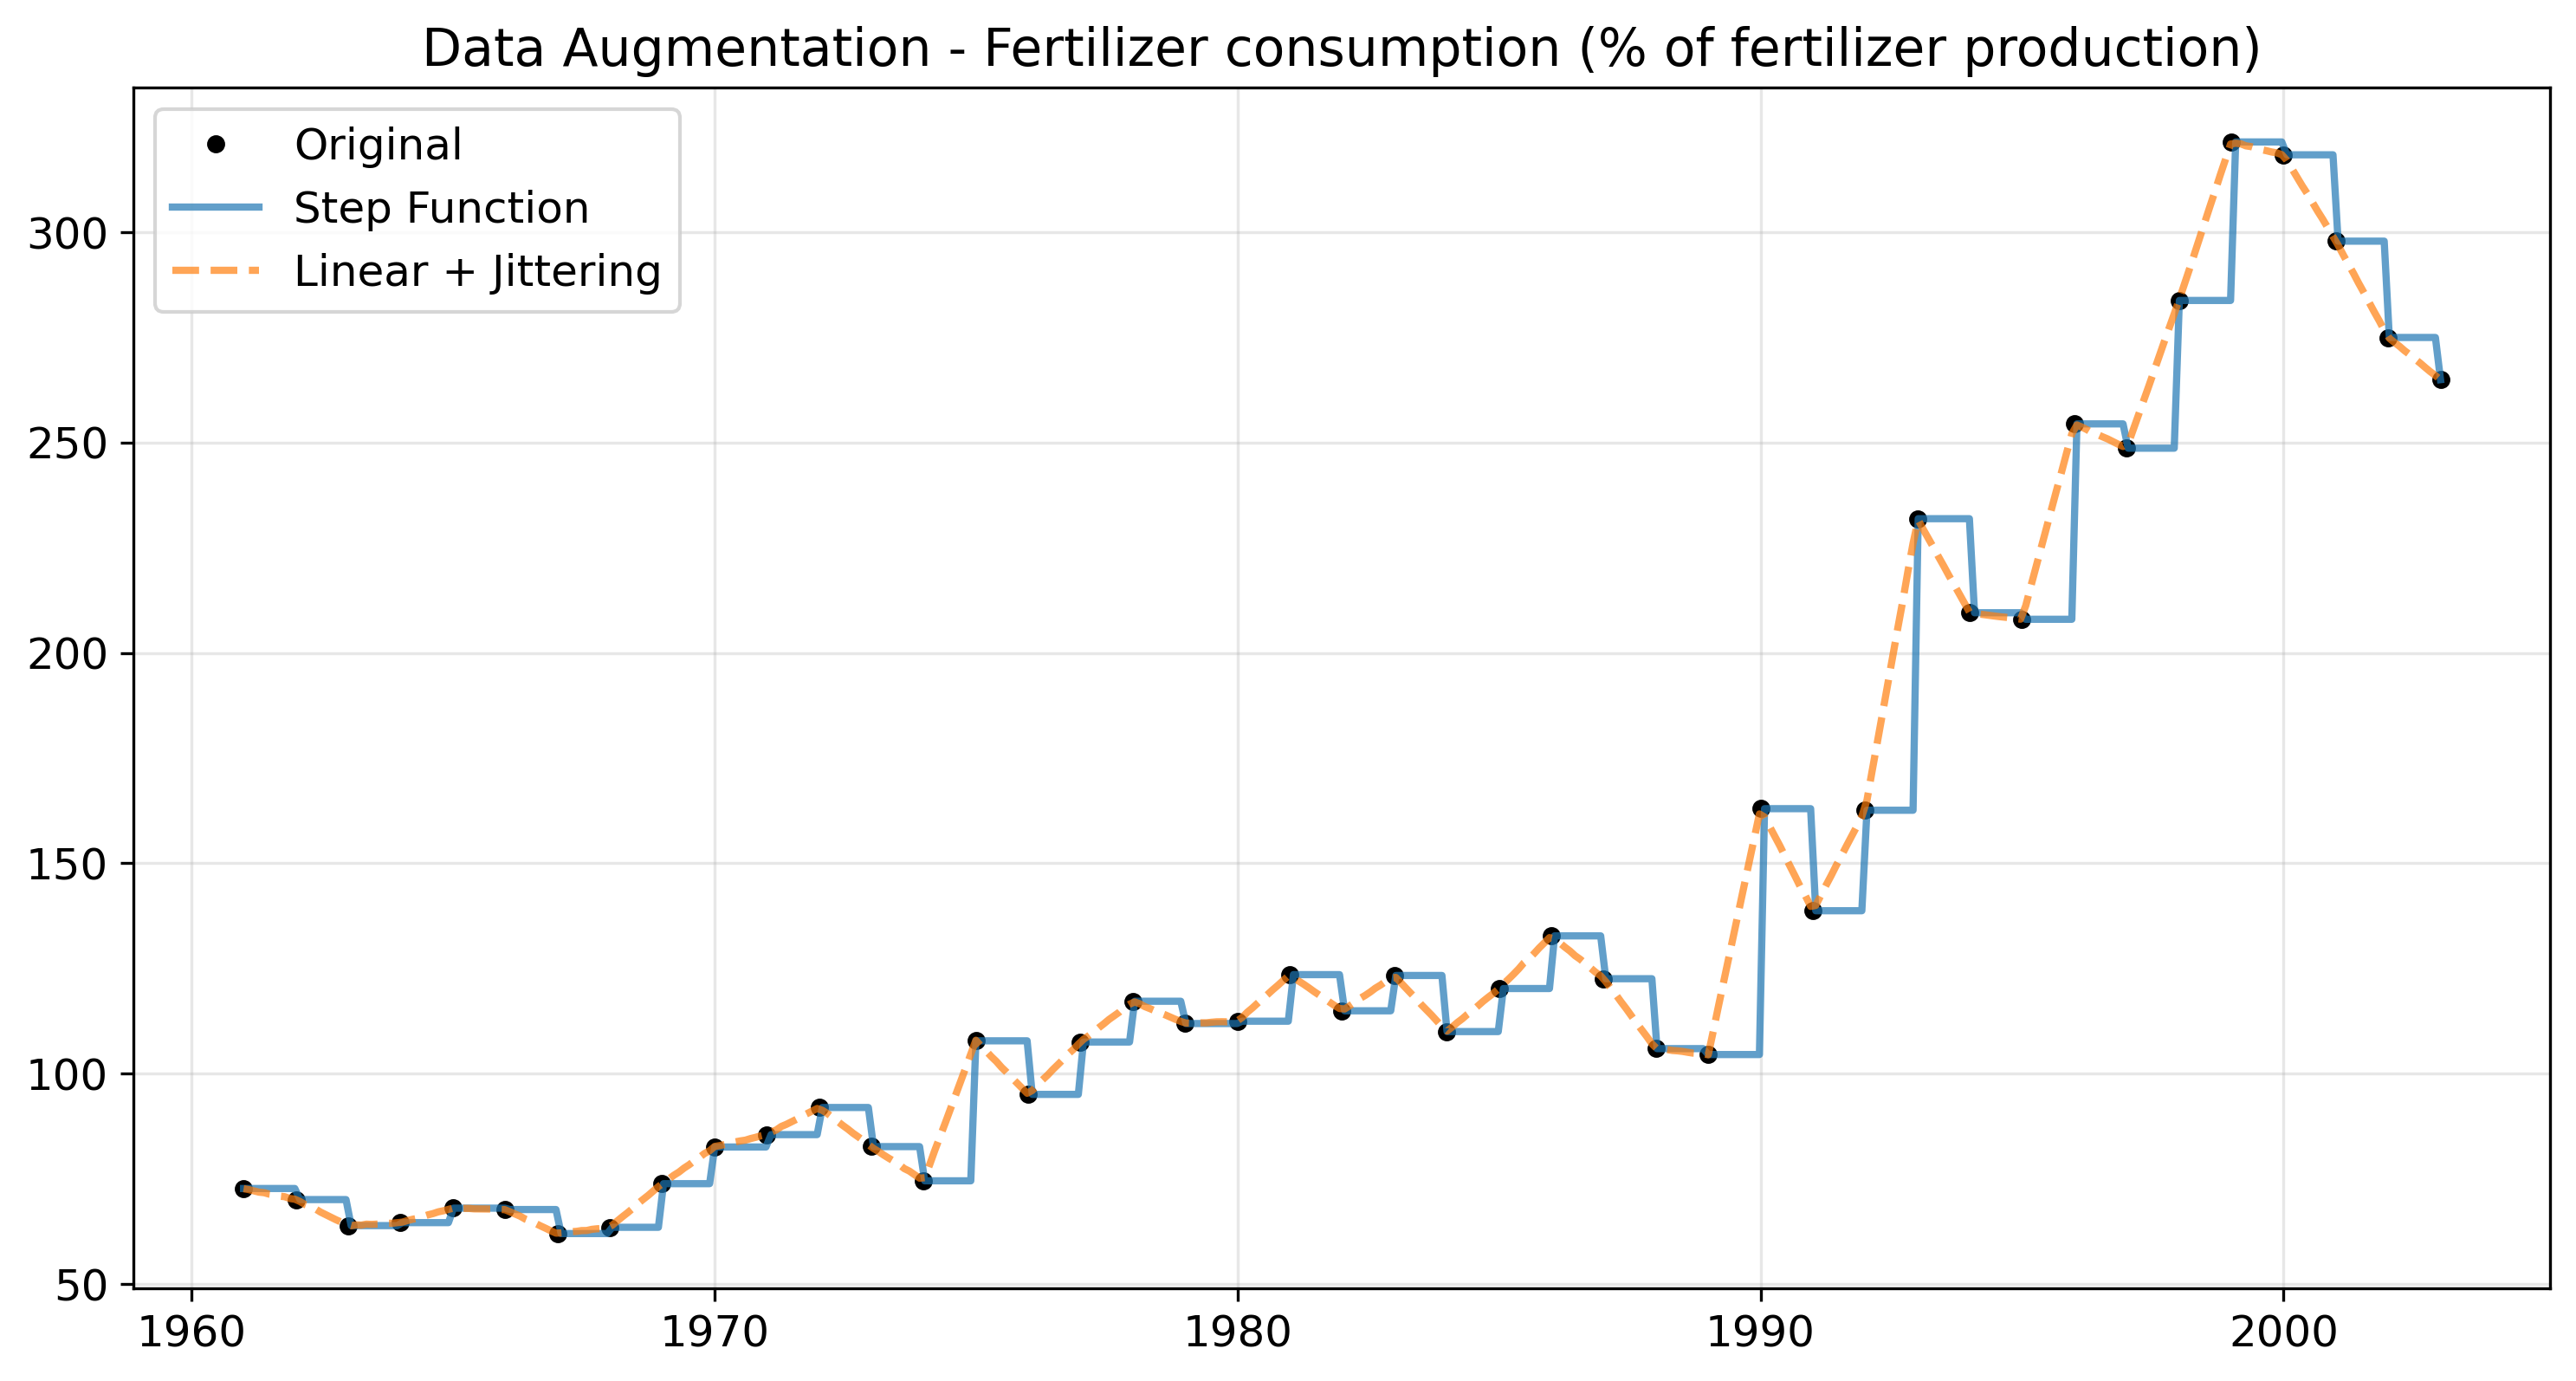

In [29]:
orig_aug_subsets = {}

for indicator in INDICATORS:
    print('='*30, indicator.upper(), '='*30)
    df_temp = df[['Year', indicator]].dropna().copy()
    df_temp.columns = ['Year', 'Value']
    train_orig, val_orig, test_orig = pipe.split_train_val_test(df_temp)    # splitto la time serie ORIGINALE
    
    x_train_vals = train_orig['Year']
    y_train_vals = train_orig['Value']
    
    df_step = pipe.augment_step_function(x_train_vals, y_train_vals, scale_factor=10)
    df_jitter = pipe.augment_linear_with_jitter(x_train_vals, y_train_vals, scale_factor=10, noise_level=0.05)
    visual.plot_augmented(indicator, df_step, df_jitter, x_train_vals, y_train_vals)
    orig_aug_subsets[indicator] = {
        'full_orig': df_temp,
        'orig_train': train_orig,
        'step_aug_train': df_step,
        'jitter_aug_train': df_jitter,
        'orig_val': val_orig,
        'orig_test': test_orig
    }

In [33]:
scaled_orig_aug_subsets = {} 
scalers_subsets = {}
for indicator in INDICATORS:
    scaled_subsets, scalers = pipe.scale_datasets(orig_aug_subsets[indicator])
    scaled_orig_aug_subsets[indicator] = scaled_subsets
    scalers_subsets[indicator] = scalers

In [1]:
scaled_table_subsets = {}
for indicator in INDICATORS:
    window_size = 3
    table_train_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_train'], window_size, step=1)
    table_train_step = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['step_aug_train'], window_size, step=1)
    table_train_jitter = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['jitter_aug_train'], window_size, step=1)
    table_val_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_val'], window_size, step=1)
    table_test_orig = pipe.create_lag_features_table(scaled_orig_aug_subsets[indicator]['orig_test'], window_size, step=1)
    scaled_table_subsets[indicator] = {
        'train_orig' : table_train_orig,
        'train_step' : table_train_step,
        'train_jitter' : table_train_jitter,
        'val_orig' : table_val_orig,
        'test_orig' : table_test_orig
    }
    display(scaled_table_subsets[indicator])

NameError: name 'INDICATORS' is not defined

## Reshape

In [ ]:
final_table_train_sets = {}
final_table_val_test_sets = {}

for indicator in INDICATORS:
    # X: filtra colonne ts_*
    # y: prende colonna 'target'
    X_train_orig_to_reshape = scaled_table_subsets[indicator]['train_orig'].filter(regex=r'^ts_').copy()
    y_train_orig_to_reshape = scaled_table_subsets[indicator]['train_orig']['target'].copy()
    
    X_train_step_to_reshape = scaled_table_subsets[indicator]['train_step'].filter(regex=r'^ts_').copy()
    y_train_step_to_reshape = scaled_table_subsets[indicator]['train_step']['target'].copy()
    
    X_train_jitter_to_reshape = scaled_table_subsets[indicator]['train_jitter'].filter(regex=r'^ts_').copy()
    y_train_jitter_to_reshape = scaled_table_subsets[indicator]['train_jitter']['target'].copy()
    
    X_val_orig_to_reshape = scaled_table_subsets[indicator]['val_orig'].filter(regex=r'^ts_').copy()
    y_val_orig_to_reshape = scaled_table_subsets[indicator]['val_orig']['target'].copy()
    
    X_test_orig_to_reshape = scaled_table_subsets[indicator]['test_orig'].filter(regex=r'^ts_').copy()
    y_test_orig_to_reshape = scaled_table_subsets[indicator]['test_orig']['target'].copy()
    
    # Reshape X: (samples, window_size, 1)
    X_train_orig = X_train_orig_to_reshape.values.reshape((X_train_orig_to_reshape.shape[0], X_train_orig_to_reshape.shape[1], 1))
    X_train_step = X_train_step_to_reshape.values.reshape((X_train_step_to_reshape.shape[0], X_train_step_to_reshape.shape[1], 1))
    X_train_jitter = X_train_jitter_to_reshape.values.reshape((X_train_jitter_to_reshape.shape[0], X_train_jitter_to_reshape.shape[1], 1))
    X_val_orig = X_val_orig_to_reshape.values.reshape((X_val_orig_to_reshape.shape[0], X_val_orig_to_reshape.shape[1], 1))
    X_test_orig = X_test_orig_to_reshape.values.reshape((X_test_orig_to_reshape.shape[0], X_test_orig_to_reshape.shape[1], 1))
    
    # Reshape y: (samples, 1)
    y_train_orig = y_train_orig_to_reshape.values.reshape(-1, 1)
    y_train_step = y_train_step_to_reshape.values.reshape(-1, 1)
    y_train_jitter = y_train_jitter_to_reshape.values.reshape(-1, 1)
    y_val_orig = y_val_orig_to_reshape.values.reshape(-1, 1)
    y_test_orig = y_test_orig_to_reshape.values.reshape(-1, 1)
    
    final_table_train_sets[indicator] = {
        'train_original' : (X_train_orig, y_train_orig),
        'train_step' : (X_train_step, y_train_step),
        'train_jitter' : (X_train_jitter, y_train_jitter),
    }
    
    final_table_val_test_sets[indicator] = {
        'validation_original': (X_val_orig, y_val_orig),
        'test_original' : (X_test_orig, y_test_orig)
    }
    
    # print("train orig", X_train_orig[0], y_train_orig[0])
    # print("step", X_train_step[0], y_train_step[0])
    # print("jitter", X_train_jitter[0], y_train_jitter[0])
    # print("val", X_val_orig[0], y_val_orig[0])
    # print("test", X_test_orig[0], y_test_orig[0])

Input layer: shape (window_size, 1)

Conv1D: 32-64 filtri, kernel_size=3, activation='relu'

MaxPooling1D: pool_size=2

Flatten: appiattisce output convoluzionale

Dense: 50-100 neuroni, activation='relu' (opzionale)

Output Dense: 1 neurone, activation='linear' (forecasting)

Parametri Architetturali
- n_filters: numero di filtri Conv1D (es. 32, 64, 128)
- kernel_size: dimensione kernel convoluzionale (es. 3, 5)
- n_conv_layers: numero di layer convoluzionali (es. 1-3 per shallow)
- pool_size: dimensione MaxPooling (es. 2)
- dense_units: neuroni nel layer Dense dopo Flatten (opzionale)
- dropout: tasso dropout per regolarizzazione
- activation: funzione attivazione ('relu', 'tanh')

Parametri Training (già gestiti da train_model)
- learning_rate, batch_size, epochs, patience

In [ ]:
params_shallow_cnn = {
    'n_filters': 32,
    'kernel_size': 3,
    'n_conv_layers': 1,
    'pool_size': 2,
    'use_pooling': True,
    'dense_units': 50,
    'dropout': 0.2,
    'activation': 'relu',
    'learning_rate': 0.001
}

for indicator in INDICATORS:
    for augmentation in ['original', 'step', 'jitter']:
        X = final_table_train_sets[indicator][f'train_{augmentation}'][0]
        y = final_table_train_sets[indicator][f'train_{augmentation}'][1]

        X_val = final_table_val_test_sets[indicator]['validation_original'][0]
        y_val = final_table_val_test_sets[indicator]['validation_original'][1]
        
        X_test = final_table_val_test_sets[indicator]['test_original'][0]
        
        scaler = scalers_subsets[indicator]
        
        input_shape = (X.shape[1], X.shape[2])  # (3, 1)
        model = nn.build_cnn_model(params_shallow_cnn, input_shape)

        history, trained_model = nn.train_model(
            model, 
            X, y,
            X_val, y_val,
            batch_size=8,
            epochs=100,
            patience=15
        )
        
        pred_scaled = model.predict(X_test, verbose=0)
        pred_real = scaler.inverse_transform(pred_scaled)

Optimizer: Adam (learning_rate=0.001)

Loss: 'mse' o 'mae'

Metrics: ['mae'] o ['mse']

INIZIO TRAINING CNN ENSEMBLE

Dataset: Originale (Shape: (47, 5, 1))
CNN ENSEMBLE RMSE: 2.5006

Dataset: Step Function (Shape: (515, 5, 1))
CNN ENSEMBLE RMSE: 2.7856

Dataset: Linear + Jitter (Shape: (515, 5, 1))
CNN ENSEMBLE RMSE: 2.7778

--- RISULTATI CNN ---


,Dataset,RMSE_CNN,MAE_CNN
0,Originale,2.500619,2.429782
2,Linear + Jitter,2.777820,2.715867
1,Step Function,2.785615,2.723506


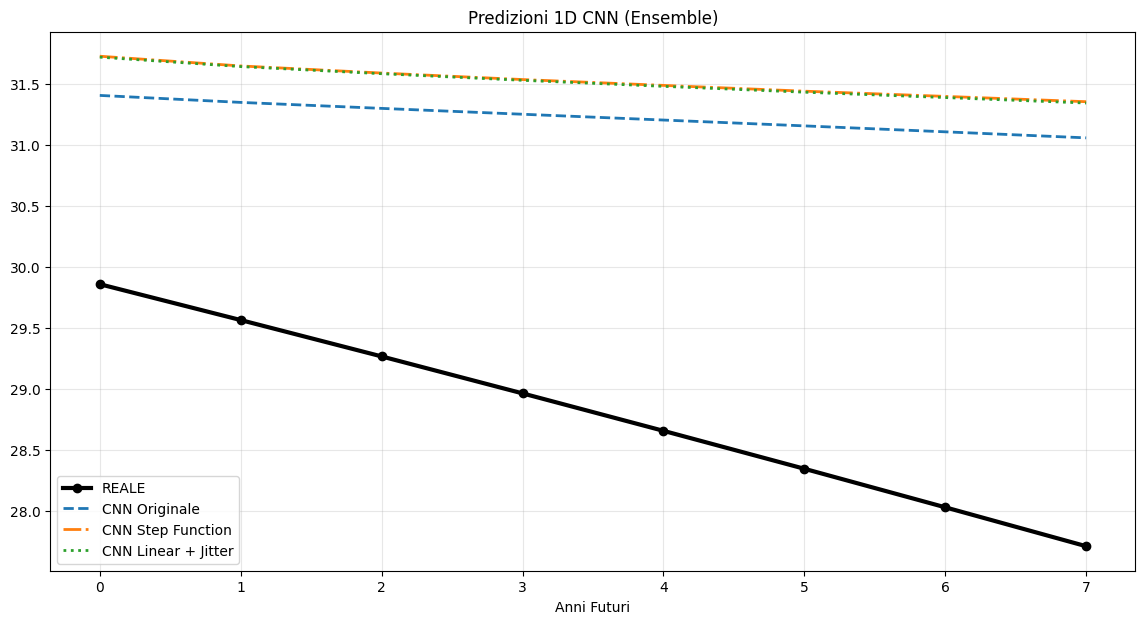

In [ ]:
N_RUNS_CNN = 5
seeds = [42, 123, 456, 789, 1000]
input_features = 1 # Abbiamo solo la 'Value'

results_cnn = {}
metrics_cnn = []

print(f"INIZIO TRAINING CNN ENSEMBLE")

for name, (curr_X, curr_y) in training_sets.items():
    
    # *** RESHAPE PER CNN ***
    # Da (N, 5) diventa (N, 5, 1)
    X_cnn = curr_X.reshape((curr_X.shape[0], curr_X.shape[1], 1))
    X_test_cnn = X_test.reshape((X_test.shape[0], X_test.shape[1], 1))
    
    print(f"\nDataset: {name} (Shape: {X_cnn.shape})")
    
    all_predictions = np.zeros((N_RUNS_CNN, len(X_test)))
    
    for i in range(N_RUNS_CNN):
        reset_seeds(seeds[i]) 
        
        model = build_cnn_model(input_features, WINDOW_SIZE)
        
        history = model.fit(
            X_cnn, curr_y,
            epochs=150, # Le CNN spesso convergono prima
            batch_size=16,
            validation_data=(X_test_cnn, y_test),
            verbose=0,
            callbacks=[early_stop, reduce_lr],
            shuffle=True
        )
        
        pred_scaled = model.predict(X_test_cnn, verbose=0)
        pred_real = scaler.inverse_transform(pred_scaled).flatten()
        all_predictions[i, :] = pred_real

    # Media Ensemble
    ensemble_pred = np.mean(all_predictions, axis=0)
    
    # Metriche
    rmse_ens = np.sqrt(mean_squared_error(y_test_real, ensemble_pred))
    mae_ens = mean_absolute_error(y_test_real, ensemble_pred)
    
    results_cnn[name] = ensemble_pred
    metrics_cnn.append({"Dataset": name, "RMSE_CNN": rmse_ens, "MAE_CNN": mae_ens})
    
    print(f"CNN ENSEMBLE RMSE: {rmse_ens:.4f}")

# --- CONFRONTO FINALE MLP vs CNN ---
df_cnn = pd.DataFrame(metrics_cnn).sort_values(by="RMSE_CNN")
print("\n--- RISULTATI CNN ---")
display(df_cnn)

# Plot CNN
plt.figure(figsize=(14, 7))
plt.plot(range(len(y_test_real)), y_test_real, 'o-', label='REALE', color='black', linewidth=3)
styles = ['--', '-.', ':']
for i, (name, preds) in enumerate(results_cnn.items()):
    plt.plot(range(len(y_test_real)), preds, styles[i], label=f'CNN {name}', linewidth=2)

plt.title("Predizioni 1D CNN (Ensemble)")
plt.xlabel("Anni Futuri")
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()